# Analisis Exploratorio Continuacion
## Mario Alejandro Castro Lerma

Continuacion de EDA a partir del dataset rick_eda_imput.csv generado por Esthefania en 2.1-eot-EDA_PCA.ipynb

---

### Analisis rapido

In [121]:
import pandas as pd
import numpy as np

In [122]:
df = pd.read_csv("../data/interim/rick_eda_imput.csv")
# df = pd.read_csv("../data/interim/rick_hist.csv")

In [123]:
df.head()

,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,dias_estudio,demora_pac,demora_pac_fiebre,demora_pac_signos_alarma,fec_ini_estudio_corr,fec_fin_estudio_corr,fec_sol_aten_corr,fec_ini_signos_alarma_corr,fec_ini_signos_sint_corr,fec_ini_fiebre_corr
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.0,...,7.0,2,2.0,1.0,False,False,False,False,False,False
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.0,...,NaN,1,1.0,NaN,False,False,False,False,False,False
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.0,...,0.0,3,3.0,NaN,False,False,False,False,False,False
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.0,...,NaN,3,2.0,NaN,False,False,False,False,False,False
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.0,...,24.0,8,8.0,NaN,False,False,False,False,False,False


Por nota de Esthefania eliminare _corr, _imput, _uni_trat y otras columnas

In [124]:
cols_to_remove = [col for col in df.columns if col.endswith(('_corr', '_imput', '_uni_trat'))]
cols_to_remove += ['ide_cp', 'des_diag_final', 'compromiso_organos'] 
print(f"Columns to remove: {cols_to_remove}")
df = df.drop(columns=cols_to_remove)

Columns to remove: ['des_jur_uni_trat', 'des_mpo_uni_trat', 'des_ins_uni_trat', 'des_cual_lengua_imput', 'otros_especifique_imput', 'contacto_otr_imput', 'otro_sintoma_imput', 'otr_serv_atencion_imput', 'temperatura_imput', 'fec_ini_estudio_corr', 'fec_fin_estudio_corr', 'fec_sol_aten_corr', 'fec_ini_signos_alarma_corr', 'fec_ini_signos_sint_corr', 'fec_ini_fiebre_corr', 'ide_cp', 'des_diag_final', 'compromiso_organos']


In [125]:
df.shape

(2631, 172)

Columnas con vacios:

In [126]:
for col in df.columns:
    if df[col].isna().any():
        print(f"{col}: {df[col].isna().sum()}")
        

fec_ini_estudio: 2
fec_fin_estudio: 1265
fec_ini_fiebre: 80
fec_ini_signos_alarma: 2211
fec_ingreso: 1153
cve_uni_med_tratante: 810
des_unidad_tratante: 810
cve_diag_hospit: 1325
fec_egreso: 1549
fec_defuncion: 2291
fecha_toma_rickett_ser1: 1382
fecha_recep_rickett_ser1: 1610
fecha_resultado_rickett_ser1: 1640
rickett_resultado_ser1: 191
fecha_toma_rickett_sangre: 300
fecha_recep_rickett_sangre: 381
mstra_rech_ricket_sangre: 191
motiv_rech_ricket_sangre: 191
ricket_cq_lesp: 191
ricket_cq: 191
res_final_ricket_inmuno: 191
res_final_ricket_rtpcr: 191
fecha_resultado_rickett_rtpcr: 406
ricket_especie_rtpcr: 191
fec_ini_trat_ricket: 655
fec_fin_trat_ricket: 1806
des_ins_uni_trat_norm: 704
tiempo_res_hosp: 1
dias_estudio: 1263
demora_pac_fiebre: 80
demora_pac_signos_alarma: 2211


Dropeare las columnas con mas de 80% de faltantes

In [127]:
# Percentage threshold
threshold = 0.80
cols_to_drop = df.columns[df.isnull().mean() > threshold]

# Drop them
df = df.drop(columns=cols_to_drop)

# Optional: see which columns were removed
print("Dropped columns:")
print(list(cols_to_drop))

Dropped columns:
['fec_ini_signos_alarma', 'fec_defuncion', 'demora_pac_signos_alarma']


In [128]:
df.shape

(2631, 169)

---

### Separando el dataset en 2, uno para la prediccion de rickettsia y otro para predecir la letalidad

In [129]:
easy_access_cols = [

    # Demographics
    "ide_sex",
    "ide_eda_ano",
    "es_indigena",

    # Exposure
    "contacto_garrapata",
    "contacto_otr",
    "agua_potable",
    "eliminacion_basura",

    # Symptoms / signs
    "temperatura",
    "cefalea",
    "mialgias",
    "artralgias",
    "exantema",
    "nauseas",
    "vomito",
    "petequias",
    "dolor_abdominal_intenso",
    "letargo",
    "irritabilidad",
    "taquicardia",
    "fotofobia",
    "diarrea",
    "conjuntivitis",
    "tos",
    "faringitis",
    "ictericia",
    "convulsiones",
    "somolencia",
    "adinamia",
    "astenia",
    "cefalea_frontal",
    "perdida_peso",
    "escalofrios",
    "diaforesis",
    "anorexia",

    # Comorbidities
    "diabetes",
    "hipertension",
    "enf_ulcero_peptica",
    "enf_renal",
    "inmunosupresion",
    "cirrosis_hepatica",
    "embarazo",
    "sem_gest",

    # Temporal progression
    "demora_pac",
    "demora_pac_fiebre",
]

target_col = "estatus_caso"

prediction_df = df[easy_access_cols + [target_col]]

In [130]:
# Detect columns that contain only 0, 1, and/or 2
binary_cols = []

for col in prediction_df.columns:

    # Get unique non-null values
    unique_vals = set(prediction_df[col].dropna().unique())

    # Check if column only contains 0, 1, 2
    if unique_vals.issubset({0, 1, 2}):

        # Must contain at least 1 and 2 to be considered
        if 1 in unique_vals and 2 in unique_vals:
            binary_cols.append(col)

# Show detected columns
print("Detected binary columns:")
print(binary_cols)

# Recode:
# 1 -> 1 (yes)
# 2 -> 0 (no)
# 0 -> NaN (unknown)

prediction_df[binary_cols] = prediction_df[binary_cols].replace({
    1: 1,
    2: 0,
    0: np.nan
})

print("\nRecoding completed.")

Detected binary columns:
['ide_sex', 'es_indigena', 'agua_potable', 'eliminacion_basura', 'cefalea', 'mialgias', 'artralgias', 'exantema', 'nauseas', 'vomito', 'petequias', 'dolor_abdominal_intenso', 'letargo', 'irritabilidad', 'taquicardia', 'fotofobia', 'diarrea', 'conjuntivitis', 'tos', 'faringitis', 'ictericia', 'convulsiones', 'somolencia', 'adinamia', 'astenia', 'cefalea_frontal', 'perdida_peso', 'escalofrios', 'diaforesis', 'anorexia']

Recoding completed.


In [131]:
prediction_df.head() 

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,contacto_otr,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,...,hipertension,enf_ulcero_peptica,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,demora_pac,demora_pac_fiebre,estatus_caso
0,1,39,0,1,Se ignora,0.0,0.0,39.0,0.0,1.0,...,0,0,0,0,0,0,0,2,2.0,2
1,0,8,0,1,Se ignora,1.0,0.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,1,1.0,3
2,0,2,0,0,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,3,3.0,1
3,1,9,0,1,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,3,2.0,3
4,0,13,0,1,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,8,8.0,2


In [132]:
for col in prediction_df.columns:
    if prediction_df[col].isna().any():
        print(f"{col}: {prediction_df[col].isna().sum()}")

agua_potable: 72
eliminacion_basura: 88
cefalea: 3
mialgias: 5
artralgias: 4
exantema: 3
nauseas: 4
vomito: 6
petequias: 5
dolor_abdominal_intenso: 59
letargo: 59
irritabilidad: 61
taquicardia: 96
fotofobia: 56
diarrea: 55
conjuntivitis: 57
tos: 52
faringitis: 57
ictericia: 56
convulsiones: 56
somolencia: 56
adinamia: 54
astenia: 54
cefalea_frontal: 56
perdida_peso: 57
escalofrios: 52
diaforesis: 52
anorexia: 55
demora_pac_fiebre: 80


In [133]:
prediction_df['demora_pac_fiebre'].describe()

count    2551.000000
mean        2.914543
std         2.735631
min        -3.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        63.000000
Name: demora_pac_fiebre, dtype: float64

Como no sabemos la demora en esos 80 pacientes, he decidido utilizar la media.

In [134]:
prediction_df.fillna(value={'demora_pac_fiebre': prediction_df['demora_pac_fiebre'].mean()}, inplace=True)

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,contacto_otr,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,...,hipertension,enf_ulcero_peptica,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,demora_pac,demora_pac_fiebre,estatus_caso
0,1,39,0,1,Se ignora,0.0,0.0,39.0,0.0,1.0,...,0,0,0,0,0,0,0,2,2.0,2
1,0,8,0,1,Se ignora,1.0,0.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,1,1.0,3
2,0,2,0,0,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,3,3.0,1
3,1,9,0,1,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,3,2.0,3
4,0,13,0,1,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,8,8.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,0,20,0,1,Se ignora,1.0,0.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,2,2.0,2
2627,0,24,0,1,Se ignora,1.0,1.0,39.0,1.0,0.0,...,0,0,0,0,0,0,0,3,3.0,3
2628,0,20,0,1,Se ignora,1.0,1.0,39.0,1.0,1.0,...,0,0,0,0,0,0,0,8,8.0,2
2629,1,1,0,1,Se ignora,NaN,NaN,38.0,1.0,0.0,...,0,0,0,0,0,0,0,2,2.0,3


Y para el resto, al ser pocos vacios, los eliminamos

In [135]:
prediction_df.dropna(inplace=True)

In [136]:
for col in prediction_df.columns:
    if prediction_df[col].isna().any():
        print(f"{col}: {prediction_df[col].isna().sum()}")

Revisando la columna con str:

In [137]:
prediction_df['contacto_otr'].value_counts()

contacto_otr
Se ignora                    2128
Perros                        216
Perros con ectoparásitos       19
Sin contacto                   14
Perros con garrapatas           9
Perros y gatos                  9
Roedores                        4
Pulgas                          3
Garrapatas                      3
Insectos no especificados       2
Gatos                           2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Zoonosis                        1
Name: count, dtype: int64

In [138]:
prediction_df['contacto_otr'] = prediction_df['contacto_otr'].str.lower()

Este dataframe es el que utilizarmos a partir de aqui y ya se encuentra limpio, asi que lo guardare en processed

In [139]:
# Generar el CSV final para predicciones
# prediction_df.to_csv('../data/processed/rickettsia_for_predictions.csv', index = False)

### Aplicando modelo no supervisado

In [140]:
model_df = prediction_df.copy()
X = model_df.drop(columns=["estatus_caso"])
y = model_df["estatus_caso"]

trabajando con categoricas:

In [141]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(
        X_encoded[col].astype(str)
    )

C:\Users\MasterHDXD\AppData\Local\Temp\ipykernel_16828\1844065949.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_encoded.select_dtypes(include="object").columns:


escalando valores numericos:

In [142]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

#### Usando UMAP

In [143]:
import umap

umap_model = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

d:\MasterHDXD\Escuela\Maestria\MachineLearning\Rickettsia\rickettsia_sonora\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Usando hdbscan

In [144]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=10
)

clusters = clusterer.fit_predict(X_umap)

In [145]:
model_df["cluster"] = clusters

pd.crosstab(
    model_df["cluster"],
    model_df["estatus_caso"],
    normalize="index"
)

estatus_caso,1,2,3
cluster,,,
-1,0.105590,0.267081,0.627329
0,0.152542,0.237288,0.610169
1,0.098039,0.245098,0.656863
2,0.200000,0.081818,0.718182
3,0.100000,0.220000,0.680000
4,0.159091,0.113636,0.727273
5,0.140798,0.139690,0.719512
6,0.098039,0.215686,0.686275
7,0.184783,0.163043,0.652174


Visualizar los datos

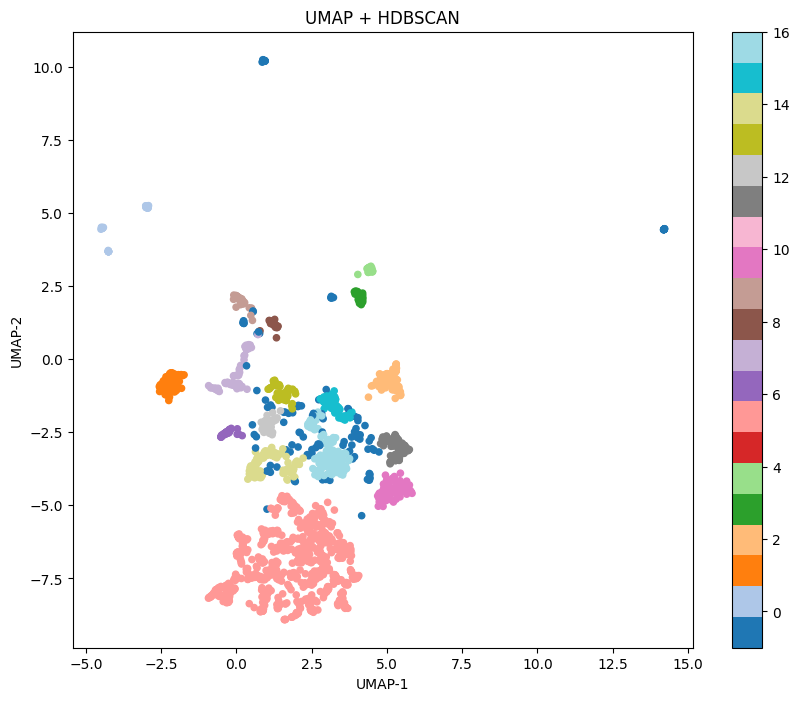

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="tab20",
    s=20
)

plt.colorbar(scatter)

plt.title("UMAP + HDBSCAN")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

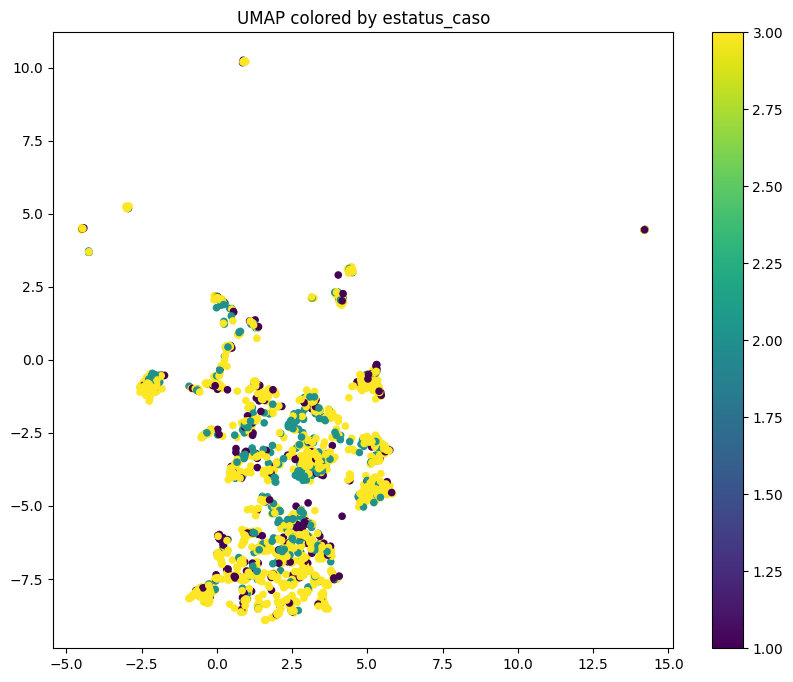

In [147]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="viridis",
    s=20
)

plt.colorbar(scatter)

plt.title("UMAP colored by estatus_caso")

plt.show()

Aunque podemos observar que se separan claramente en clusters en la primera grafica, al colorear por estatus_caso, podemos ver que los casos verificados de rickettsia no se separan claramente entre los grupos que se arman.

In [148]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

outliers = iso.fit_predict(X_scaled)

model_df["outlier"] = outliers

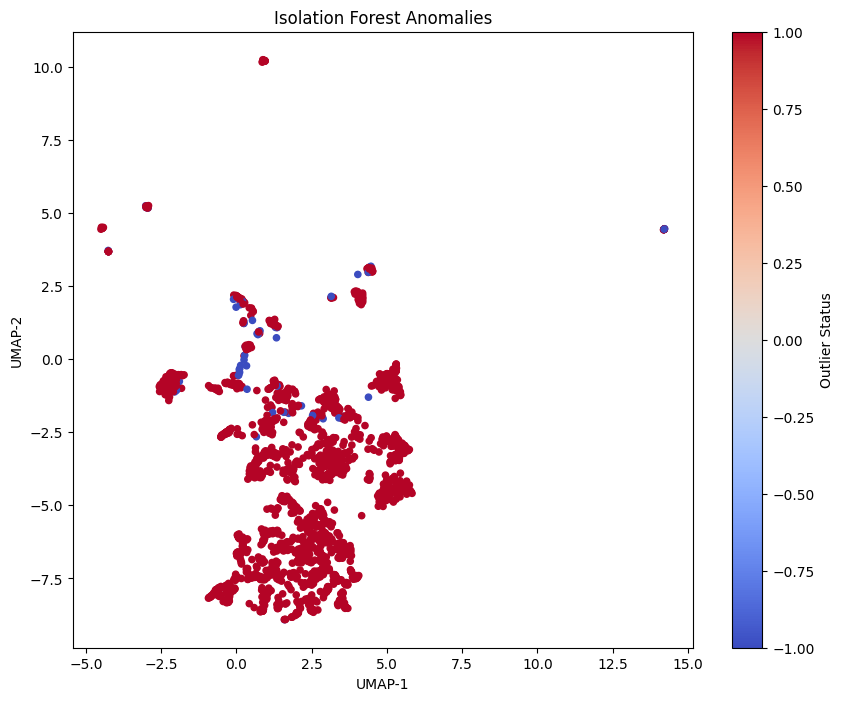

In [149]:

plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=model_df["outlier"],
    cmap="coolwarm",
    s=20
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.colorbar(label="Outlier Status")

plt.show()

In [150]:
anomalies_df = model_df[
    model_df["outlier"] == -1
]

normal_df = model_df[
    model_df["outlier"] == 1
]

In [151]:
comparison = pd.DataFrame({
    "normal_mean": normal_df.mean(numeric_only=True),
    "anomaly_mean": anomalies_df.mean(numeric_only=True)
})

comparison["difference"] = (
    comparison["anomaly_mean"] -
    comparison["normal_mean"]
)


In [152]:
comparison.sort_values(
    "difference",
    ascending=False
).head(20)

,normal_mean,anomaly_mean,difference
ide_eda_ano,24.214255,35.671233,11.456978
demora_pac,3.120785,4.136986,1.016201
demora_pac_fiebre,2.914439,3.848144,0.933705
somolencia,0.042254,0.602740,0.560486
adinamia,0.287665,0.780822,0.493157
letargo,0.119078,0.589041,0.469963
astenia,0.284678,0.739726,0.455048
escalofrios,0.287665,0.739726,0.452061
irritabilidad,0.217243,0.643836,0.426593
taquicardia,0.123346,0.547945,0.424599


Podemos notar aqui que es una anomalia presentar la mayoria de los sintomas, mientras que la poblacion general no suele presentar la mayoria de los sintomas. 

Tambien se puede ver que las personas con las anomalias suelen tener una mayor edad comparado al resto de la poblacion.

Estas observaciones nos dan una pista para cuando queramos realizar las prediciones despues.